In [1]:
import sys
sys.path.append("/project/src")

In [2]:
# Helper imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sksurv.metrics import concordance_index_censored

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    BaseDatasetPreprocessor,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
    low_missingness_complete_case_analysis,
    split_features_target,
    concat_features_target
)
from helpers import save_pic

import wandb
import joblib

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2025.csv"

In [4]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_1062/2070981678.py:1: DtypeWarning: Columns (4,8,10,21,25,27,28,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,138,149,190,193,195,201,203,205,207,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,405,418,425,465,545,576,601,636,652,669,672,689,700,706,758,760,762,763,769,792,805,813,814,815,816,826,848,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [5]:
nacc_raw.head()

,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,1.0,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.487
1,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.035
2,2.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.474
3,1.0,2,0.0,NaN,NaN,1.0,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.025
4,NaN,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2.012


In [6]:
print(f"shape {nacc_raw.shape}")

shape (17477, 857)


# Train test split

In [7]:
train_df, test_df = train_test_split(
    nacc_raw,
    test_size=0.2,
    random_state=42,
    stratify=nacc_raw['EVENT_MCI'],
)

In [8]:
train_df.to_csv("./data/nacc_train.csv", index=False)
test_df.to_csv("./data/nacc_test.csv", index=False)

In [9]:
train_df = low_missingness_complete_case_analysis(train_df)

Complete-case analysis on low-missing columns
Defining missingness


# Feature selection RSF VIMP tunning

In [10]:
X_train_for_tunning, y_train_for_tunning = split_features_target(train_df)

In [11]:
features_num = X_train_for_tunning.shape[1]
n_samples = X_train_for_tunning.shape[0]

# Start a new  run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="xportnykh-slovak-technical-university-in-bratislava",
    # Set the wandb project where this run will be logged.
    project="mci-survival-analysis",
)

wandb.define_metric("trees/*", step_metric="trees/num_trees")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: xportnykh (xportnykh-slovak-technical-university-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [12]:
class NodeSizeDistribution:
    def __init__(self, n_samples):
        self.n = n_samples
    
    def rvs(self, random_state=None):
        x = uniform(0, 1).rvs(random_state=random_state)
        return max(20, round(self.n ** x))

def concordance_index_scorer(estimator, X, y):
    try:
        risk_scores = estimator.predict(X)
        c_index = concordance_index_censored(
            y[SURVIVAL_EVENT_COL].astype(bool),
            y[SURVIVAL_TIME_COL],
            risk_scores
        )[0]
        return c_index

    except Exception as e:
        rsf_step = estimator.named_steps['model'] if hasattr(estimator, 'named_steps') else estimator
        print(f"Scorer failed — parameters that caused the error:")
        print(f"  min_node_size:   {rsf_step.min_node_size}")
        print(f"  mtry:            {rsf_step.mtry}")
        print(f"  replace:         {rsf_step.replace}")
        print(f"  sample_fraction: {rsf_step.sample_fraction:.4f}")
        print(f"  Error type:      {type(e).__name__}")
        print(f"  Error message:   {e}")
        raise

In [13]:
tunning_pipeline = Pipeline([
  ('preprocessor', BaseDatasetPreprocessor()),
  ('model', RandomSurvivalForest())
])

In [ ]:
cv = StratifiedKFold(n_splits=5)
event_indicator = y_train_for_tunning[SURVIVAL_EVENT_COL].astype(int)
cv_splits = list(cv.split(X_train_for_tunning, event_indicator))

param_distributions = {
    'model__num_trees':        np.arange(100, 550, 50),
    'model__mtry':             ['sqrt', 'log2'],
    'model__min_node_size':    NodeSizeDistribution(n_samples),
    'model__replace':          [True, False],
    'model__sample_fraction':  uniform(0.1, 0.9),
}

random_search = RandomizedSearchCV(
    estimator=tunning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv_splits,
    scoring=concordance_index_scorer,
)

random_search.fit(X_train_for_tunning, y_train_for_tunning)
results_df = pd.DataFrame(random_search.cv_results_)



Fitting structural cleanup
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns
Apply MNAR placeholder imputation
Colapsing rare categories
Apply One-Hot-Encoding


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  



Running Random Survival Forest with parameters: num_trees=250, min_node_size=20, mtry=log2, splitrule='C', importance='none', compute_weights=True, replace=False, sample_fraction=0.7696393139344955
Growing trees.. Progress: 23%. Estimated remaining time: 1 minute, 44 seconds.
Growing trees.. Progress: 47%. Estimated remaining time: 1 minute, 10 seconds.
Growing trees.. Progress: 70%. Estimated remaining time: 39 seconds.
Growing trees.. Progress: 96%. Estimated remaining time: 5 seconds.
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


Fitting structural cleanup
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns
Apply MNAR placeholder imputation
Colapsing rare categories
Apply One-Hot-Encoding

Running Random Survival Forest with parameters: num_trees=250, min_node_size=20, mtry=log2, splitrule='C', importance='non

In [15]:
wandb.log({
    "cv/results_table": wandb.Table(dataframe=results_df[[
        "mean_test_score",
        "std_test_score",
        "param_model__num_trees",
        "param_model__mtry",
        "param_model__min_node_size",
        "param_model__replace",
        "param_model__sample_fraction",
    ]])
})

In [16]:
rsf_vimp_best_params = {
    k.replace('model__', ''): v
    for k, v in random_search.best_params_.items()
}

In [17]:
rsf_vimp_best_params

{'min_node_size': 20,
 'mtry': 'sqrt',
 'num_trees': np.int64(400),
 'replace': False,
 'sample_fraction': np.float64(0.6194516923834537)}

In [18]:
# Preprocess full training set using the best pipeline's fitted preprocessor
best_preprocessor = random_search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = best_preprocessor.transform(X_train_for_tunning)

Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [19]:
processed_train_df = concat_features_target(X_train_preprocessed, y_train_for_tunning)
processed_train_df.to_csv("./data/nacc_train_tunning_preprocessed.csv", index=False)

In [20]:
tree_count = np.arange(100, 550, 50)
train_errors = []
oob_errors = []

for n_trees in tree_count:
    rsf = RandomSurvivalForest(
        num_trees=n_trees,
        mtry=rsf_vimp_best_params['mtry'],
        min_node_size=rsf_vimp_best_params['min_node_size'],
        replace=rsf_vimp_best_params['replace'],
        sample_fraction=rsf_vimp_best_params['sample_fraction'],
        splitrule="C",
        compute_weights=True,
        OOB_score=True,
    )
    rsf.fit(X_train_preprocessed, y_train_for_tunning)

    oob_error = rsf.oob_error()
    oob_errors.append(oob_error)
    train_error = 1 - rsf.score(X_train_preprocessed, y_train_for_tunning)
    train_errors.append(train_error)

    error_gap = oob_error - train_error

    wandb.log({
        "trees/num_trees":   n_trees,
        "trees/oob_error":   oob_error,
        "trees/train_error": train_error,
        "trees/gap":         error_gap,
    })


Running Random Survival Forest with parameters: num_trees=100, min_node_size=20, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=False, sample_fraction=0.6194516923834537
Growing trees.. Progress: 30%. Estimated remaining time: 1 minute, 14 seconds.
Growing trees.. Progress: 61%. Estimated remaining time: 40 seconds.
Growing trees.. Progress: 93%. Estimated remaining time: 7 seconds.

Running Random Survival Forest with parameters: num_trees=150, min_node_size=20, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=False, sample_fraction=0.6194516923834537
Growing trees.. Progress: 18%. Estimated remaining time: 2 minutes, 21 seconds.
Growing trees.. Progress: 38%. Estimated remaining time: 1 minute, 44 seconds.
Growing trees.. Progress: 55%. Estimated remaining time: 1 minute, 20 seconds.
Growing trees.. Progress: 75%. Estimated remaining time: 43 seconds.
Growing trees.. Progress: 93%. Estimated remaining time: 11 seconds.

Running R

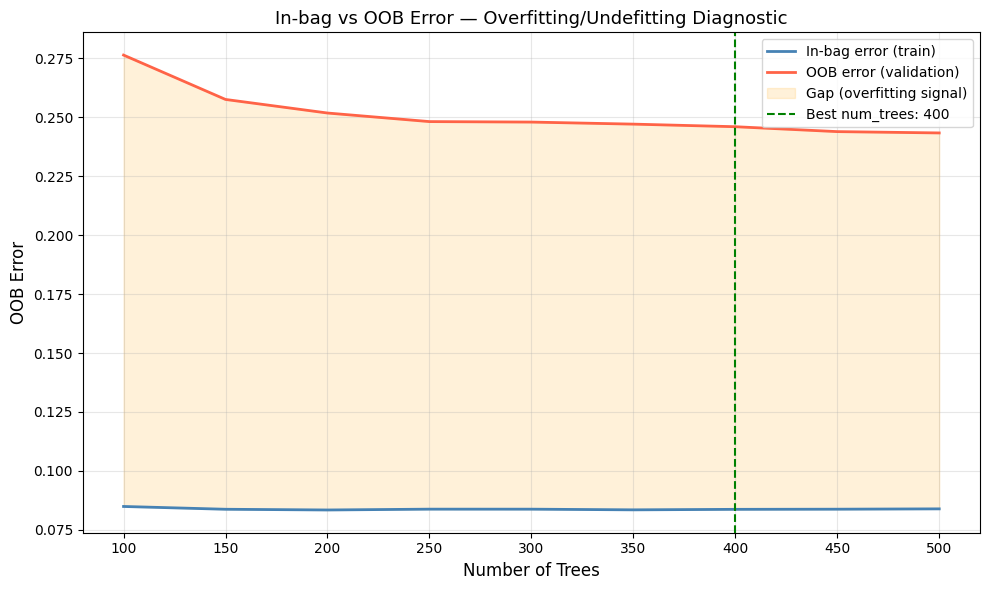

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tree_count, train_errors, color="steelblue", linewidth=2, label="In-bag error (train)")
ax.plot(tree_count, oob_errors,   color="tomato",    linewidth=2, label="OOB error (validation)")

ax.fill_between(
    tree_count, train_errors, oob_errors,
    alpha=0.15, color="orange", label="Gap (overfitting signal)"
)

ax.axvline(rsf_vimp_best_params['num_trees'], color="green", linestyle="--", linewidth=1.5, label=f"Best num_trees: {rsf_vimp_best_params['num_trees']}")

ax.set_xlabel("Number of Trees", fontsize=12)
ax.set_ylabel("OOB Error", fontsize=12)
ax.set_title("In-bag vs OOB Error — Overfitting/Undefitting Diagnostic", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_pic(plt, "oob_inbag_curves.png")
plt.show()

In [22]:
wandb.log({"curves/oob_inbag_diagnostic": wandb.Image("figures/oob_inbag_curves.png")})

In [31]:
tree_count[6], oob_errors[6], train_errors[6]

(np.int64(400), 0.24598226771735932, np.float64(0.0836867426404454))

In [24]:
oob_errors[3] - train_errors[3]

np.float64(0.16438859351479662)

In [25]:
1 - oob_errors[3], 1 - train_errors[3]

(0.7518464141167875, np.float64(0.9162350076315842))

In [26]:
best_parameters = {
    "num_trees":       rsf_vimp_best_params['num_trees'],
    "mtry":            rsf_vimp_best_params['mtry'],
    "min_node_size":   rsf_vimp_best_params['min_node_size'],
    "replace":         rsf_vimp_best_params['replace'],
    "sample_fraction": rsf_vimp_best_params['sample_fraction'],
}

In [27]:
joblib.dump(random_search.best_params_, "joblib-storage/rsf_vimp_best_params.joblib")
joblib.dump(best_parameters, "joblib-storage/rsf_vimp_best_params_processed.joblib")

['joblib-storage/rsf_vimp_best_params_processed.joblib']

In [28]:
wandb.log({"best_parameters": best_parameters})
wandb.finish()

trees/gap,█▄▃▂▂▂▂▁▁
trees/num_trees,▁▂▃▄▅▅▆▇█
trees/oob_error,█▄▃▂▂▂▂▁▁
trees/train_error,█▂▁▃▃▁▂▃▃
trees/gap,0.15945
trees/num_trees,500
trees/oob_error,0.24334
trees/train_error,0.08389
